In [1]:
import os
import math
import time
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Decoder_CLasses.ContinuousVoronoiDecoder import ContinuousVoronoiDecoder
from Utils.CADDomainVisualizer import CADDomainVisualizer
from Utils.CADVisualizer   import CADVisualizer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)


Code Directory: /home/arash/HVD_SDF
Test Step files Directory: /home/arash/HVD_SDF/Testparts
device: cuda
PyVista backend: trame



=== Active Face Info ===
XYZ bounds:
  X: [-0.000000, 10.000000]  span=10.000000
  Y: [-0.127468, 2.100919]  span=2.228387
  Z: [-2.032622, 1.938721]  span=3.971343

UV bounds:
  U: [-0.039832, 3.264132]
  V: [-5.000000, 5.000000]

Periodic:
  U periodic: False
  V periodic: False



Widget(value='<iframe src="http://localhost:43111/index.html?ui=P_0x7964ac0c7d90_0&reconnect=auto" class="pyvi…

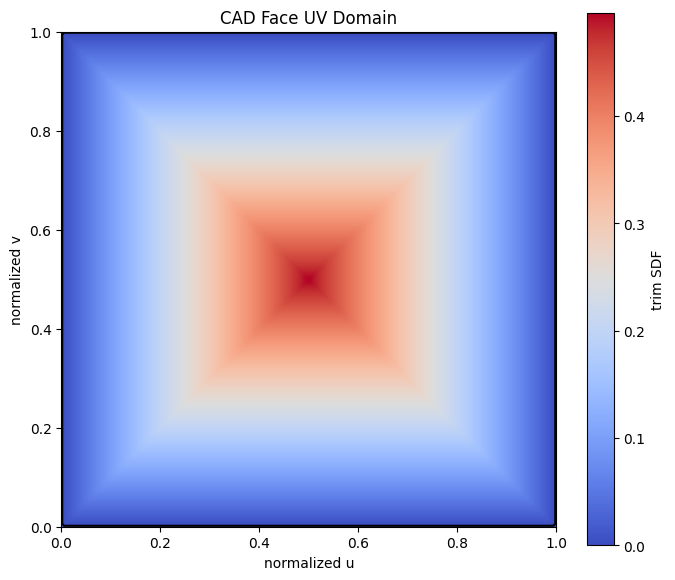

In [2]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
ConeTaped = TesPartsDir / "ConeTaped.stp"
FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
Planar = TesPartsDir / "Planar.stp"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"
FreeFormSurf4 = TesPartsDir / "FreeForm4.stp"
FreeFormBench = TesPartsDir / "FreeFormBench.stp"
FreeSharp1 = TesPartsDir / "FreeSharp1.stp"
FreeSharp2 = TesPartsDir / "FreeSharp2.stp"
SeatBr = TesPartsDir / "SeatBr.stp"
MouseBot = TesPartsDir / "MouseBot.stp"

shape_path = CircularSurf1

Face_Cad = CADTensorGenerator(
    device=device,
    seed_domain_mask_res=128,
)
domain = Face_Cad.generate_from_file(shape_path)
Face_Cad.print_face_info()
viz = CADDomainVisualizer(Face_Cad)
viz.plot_uv_domain()
viz.show_3d(res_u=200, res_v=200, show_edges=True)


In [3]:
def random_seeds_min_dist(N, min_dist=0.08, seed=1, max_tries=10000, device="cpu"):
    torch.manual_seed(seed)

    seeds = []
    tries = 0

    while len(seeds) < N and tries < max_tries:
        p = torch.rand(2, device=device)

        if len(seeds) == 0:
            seeds.append(p)
        else:
            current = torch.stack(seeds, dim=0)
            d = torch.linalg.norm(current - p[None, :], dim=-1)

            if d.min() >= min_dist:
                seeds.append(p)

        tries += 1

    if len(seeds) < N:
        raise RuntimeError(
            f"Could only generate {len(seeds)} seeds with min_dist={min_dist}."
        )

    return torch.stack(seeds, dim=0)

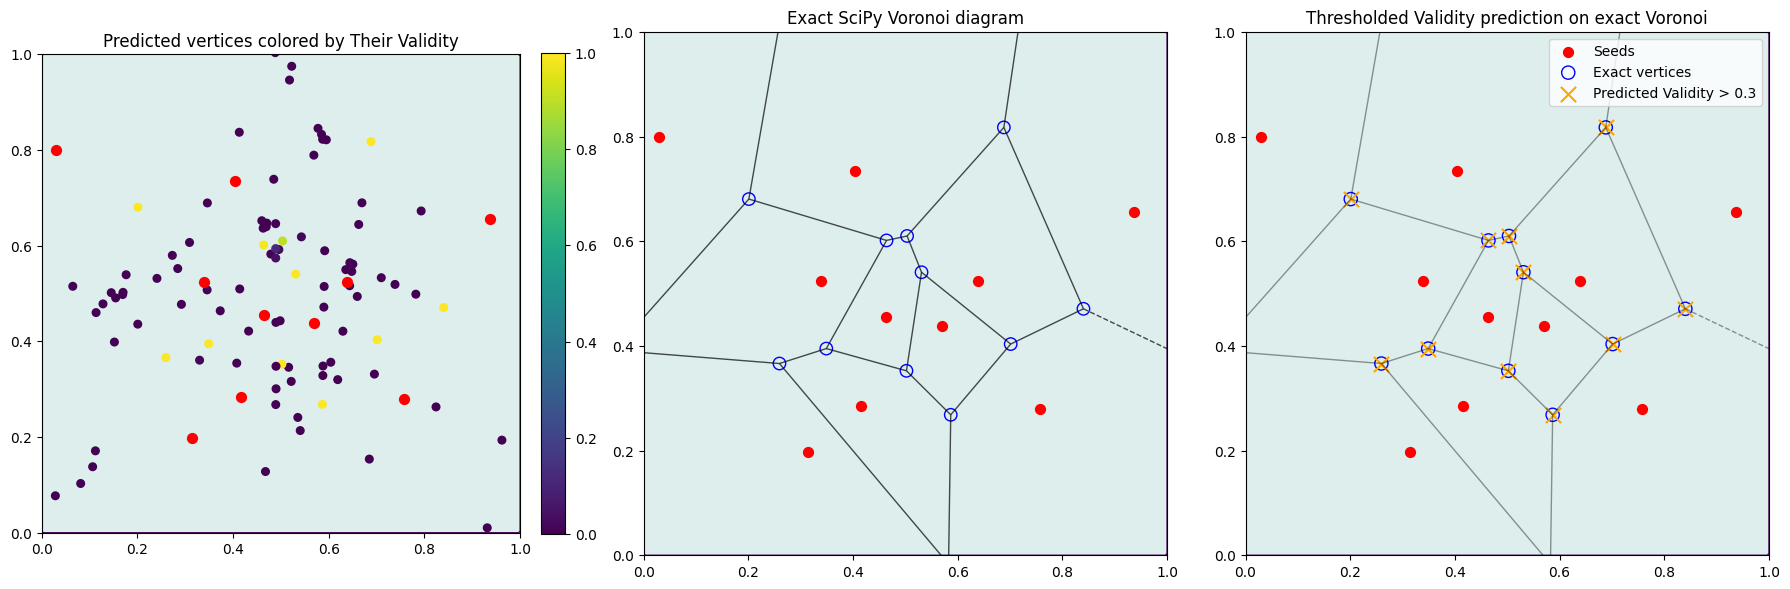

Predicted active vertices: 14
Exact inside vertices: 11
Pred -> exact mean: 1.3116694303655216
Pred -> exact max : 17.761690460363628
Exact -> pred mean: 1.0737900740894336e-05
Exact -> pred max : 3.5605883026223846e-05

No missing exact vertices with miss_tol=0.02.
All predicted Vertices Number = 120
Thresholded (0.3) predicted vertices = 14, 
alpha min =0.0, alpha max = 0.9999911189079285, alpha mean = 0.11725093424320221


In [4]:
dec = ContinuousVoronoiDecoder(
    return_xyz=False,
    min_area=1e-3,
    duplicate_merge_sigma = 0.005,
    tau_area=1e-4,
    min_seed_dist=0.01,
    tau_close=0.001,
)


N = 10
seeds = random_seeds_min_dist(
    N=N,
    min_dist=0.08,
    seed=1,
    device="cpu",
)
# seeds = torch.tensor([
#     [0.08, 0.10],
#     [0.28, 0.08],
#     [0.52, 0.10],
#     [0.74, 0.08],
#     [0.92, 0.14],

#     [0.12, 0.30],
#     [0.36, 0.26],
#     [0.60, 0.28],
#     [0.84, 0.32],

#     [0.06, 0.52],
#     [0.26, 0.48],
#     [0.50, 0.50],
#     [0.74, 0.48],
#     [0.94, 0.54],

#     [0.14, 0.72],
#     [0.38, 0.70],
#     [0.62, 0.74],
#     [0.86, 0.72],

#     [0.24, 0.92],
#     [0.76, 0.90],
# ], dtype=torch.float32)

out = dec(
    seeds,
    cad_domain=Face_Cad,   # optional; remove if testing only UV
    u_periodic=domain["u_periodic"],
    v_periodic=domain["v_periodic"],
    return_xyz=False,
)

vertices = out["vertices_uv"].detach()
alpha = out["alpha"].detach()
thr = 0.3
dec.plot_voronoi_debug(seeds,out,Face_Cad,thr,300)
print(f"All predicted Vertices Number = {vertices.shape[0]}")
print(f"Thresholded ({thr}) predicted vertices = {vertices[alpha > thr].shape[0]}, ")
print(f"alpha min ={alpha.min()}, alpha max = {alpha.max()}, alpha mean = {alpha.mean()}")


In [ ]:
vertices_all = out["vertices_uv"].detach()
alpha_all = out["alpha"].detach()

edges = out["edges"]["edge_index"]
edge_alpha = out["edges"]["edge_alpha"]

keep = alpha_all > 0.3

plt.figure(figsize=(8, 8))

# seeds
plt.scatter(
    seeds[:, 0],
    seeds[:, 1],
    c="red",
    s=60,
    label="Seeds",
)

# active vertices
plt.scatter(
    vertices_all[keep, 0],
    vertices_all[keep, 1],
    c=alpha_all[keep],
    s=20 + 120 * alpha_all[keep],
    cmap="viridis",
    label="Vertices",
)

# edges
for e, ea in zip(edges, edge_alpha):

    # only draw strong edges
    if ea.item() < 0.2:
        continue

    # only draw if both endpoints survived threshold
    if not (keep[e[0]] and keep[e[1]]):
        continue

    p0 = vertices_all[e[0]]
    p1 = vertices_all[e[1]]

    plt.plot(
        [p0[0].item(), p1[0].item()],
        [p0[1].item(), p1[1].item()],
        color="black",
        linewidth=1.5,
        alpha=float(ea),
    )

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal")
plt.colorbar(label="Vertex alpha")
plt.legend()
plt.show()

In [ ]:
dec = ContinuousVoronoiDecoder(
    return_xyz=False,
    min_area=1e-3,
    duplicate_merge_sigma = 0.005,
    tau_area=1e-4,
    min_seed_dist=0.01,
    tau_close=0.001,
)

for i in range(1, 4):
    N = 50
    seeds = random_seeds_min_dist(
        N=N,
        min_dist=0.08,
        seed=i*10,
        device="cpu",
    )
    # seeds = torch.tensor([
    #     [0.08, 0.10],
    #     [0.28, 0.08],
    #     [0.52, 0.10],
    #     [0.74, 0.08],
    #     [0.92, 0.14],

    #     [0.12, 0.30],
    #     [0.36, 0.26],
    #     [0.60, 0.28],
    #     [0.84, 0.32],

    #     [0.06, 0.52],
    #     [0.26, 0.48],
    #     [0.50, 0.50],
    #     [0.74, 0.48],
    #     [0.94, 0.54],

    #     [0.14, 0.72],
    #     [0.38, 0.70],
    #     [0.62, 0.74],
    #     [0.86, 0.72],

    #     [0.24, 0.92],
    #     [0.76, 0.90],
    # ], dtype=torch.float32)

    out = dec(
        seeds,
        cad_domain=Face_Cad,   # optional; remove if testing only UV
        u_periodic=domain["u_periodic"],
        v_periodic=domain["v_periodic"],
        return_xyz=False,
    )

    vertices = out["vertices_uv"].detach()
    alpha = out["alpha"].detach()
    thr = 0.3
    dec.plot_voronoi_debug(seeds,out,Face_Cad,thr,300)
    print(f"All predicted Vertices Number = {vertices.shape[0]}")
    print(f"Thresholded ({thr}) predicted vertices = {vertices[alpha > thr].shape[0]}, ")
    print(f"alpha min ={alpha.min()}, alpha max = {alpha.max()}, alpha mean = {alpha.mean()}")
